## Investigating : PCA 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
### so after all I am just going to use only the numerical features and then
### using the different different algos and the silhoutte score, see what's acutually going one

### data loading

In [3]:
df = pd.read_csv('../data/numerical-only.csv')
df.drop('Unnamed: 0', axis = 1, inplace = True)
df.head()

,Account_Balance,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Transaction_Amount_boxcox
0,93213.17,7,437.63,3,65,883.17,0.8494,0,5.917374
1,75725.25,13,478.76,4,186,2203.36,0.0959,0,0.860767
2,1588.96,14,50.01,4,226,1909.29,0.8400,0,5.205741
3,76807.20,8,182.48,4,76,1311.86,0.7935,0,11.399354
4,92354.66,14,328.69,4,140,966.98,0.3819,1,5.373048


### scaling the data and applying the pca

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
scaler = StandardScaler()
pca = PCA(n_components = 2)

In [6]:
df_scaled = scaler.fit_transform(df)

In [7]:
df_pca = pca.fit_transform(df_scaled)

### ----------------------clustering algos--------------------------

### 1. Kmeans clustering

In [7]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [8]:
wcss = []
for k in range(1, 12) : 
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

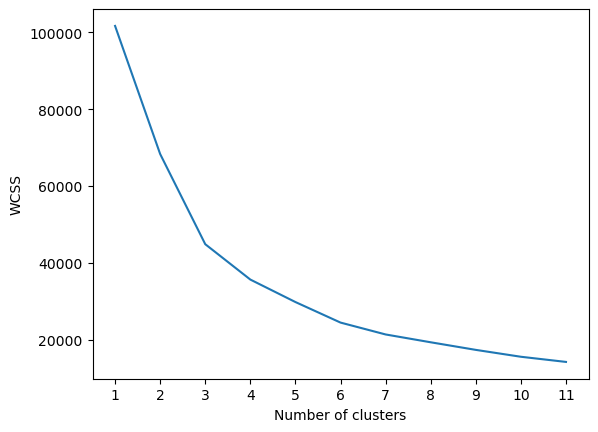

In [9]:
plt.plot(range(1, 12), wcss)
plt.xticks(range(1, 12))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [10]:
print(wcss)

[101693.61080288677, 68332.58632202866, 44855.78282806892, 35644.47743661332, 29792.347040059678, 24445.089916988527, 21352.630744727085, 19314.964450477648, 17338.174508254015, 15545.797597209426, 14201.982086632861]


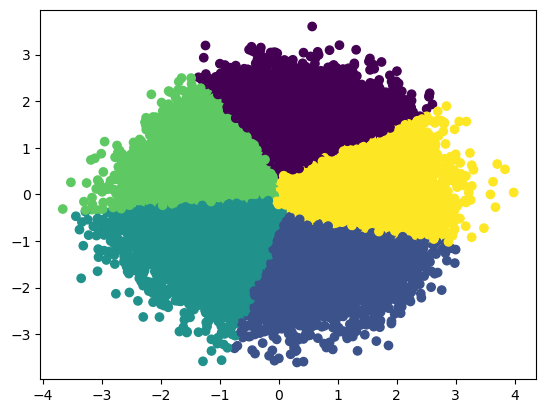

In [11]:
### taking k = 5
kmeans = KMeans(n_clusters = 5, init = 'k-means++')
y_labels = kmeans.fit_predict(df_pca)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c = y_labels)

In [12]:
print(silhouette_score(df_pca, labels = kmeans.labels_))

0.2982652002783317


### 2. DB Scan clustering

In [13]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps = 0.3)
y_labels_db = db.fit_predict(df_pca)

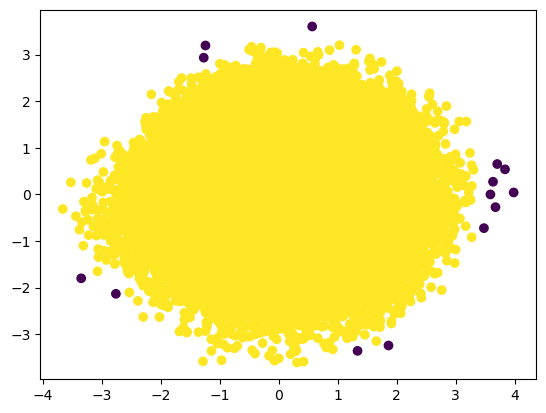

In [14]:
plt.scatter(df_pca[:, 0], df_pca[:, 1], c = y_labels_db)

In [15]:
print(silhouette_score(df_pca, labels = db.labels_))

0.5227620253396797


### 3. Hierarichal mean clustering

In [1]:
# from sklearn.cluster import AgglomerativeClustering
# hm_clutsering = AgglomerativeClustering(n_clusters = 2, linkage = 'ward')
# y_labels_hm = hm_clutsering.fit_predict(df_pca)